In [1]:
from confluent_kafka import Consumer
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from collections import Counter



In [2]:
consumer = Consumer({
    'bootstrap.servers': 'kafka:29092',
    'group.id': 'grupo_restaurante',
    'auto.offset.reset': 'earliest'
})

consumer.subscribe(['pedidos_restaurante'])



                                pedido_id         origem          cliente  \
97   d9faad2d-db90-4ec6-b0e4-20fbe2a58199  garcom_tablet            Luiza   
98   698aa267-c174-46a5-af0a-2dd7a3aef013    cliente_app            Alana   
99   d5adfd00-418e-45ed-bfb4-d5e6ddf45ef1    cliente_app              Yan   
100  35c51cbe-eb18-4d58-804e-a9caf2264981    cliente_app  Marcos Vinicius   
101  8c7905ab-6e98-449a-acd5-74a5a2bd0449  garcom_tablet    Arthur Miguel   

       garcom  mesa          item  valor      status          data_evento  
97     Marcos     1        Temaki  39.66  em_preparo  2026-05-17 18:50:33  
98     Carlos     5  Batata Frita  82.68    entregue  2026-05-17 18:50:38  
99     Marcos    10       Lasanha  47.14      pronto  2026-05-17 18:50:43  
100  Fernanda    19        Temaki  50.93      pronto  2026-05-17 18:50:48  
101    Marcos     6  Refrigerante  58.36    recebido  2026-05-17 18:50:53  


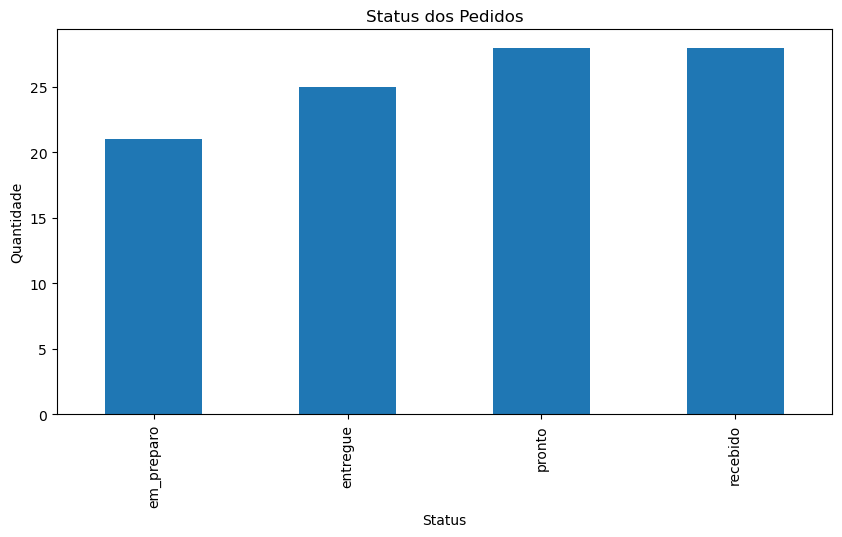

In [ ]:
pedidos = []

print('Consumindo pedidos...')

while True:

    msg = consumer.poll(1.0)

    if msg is None:
        continue

    if msg.error():
        continue

    pedido = json.loads(msg.value().decode('utf-8'))

    pedidos.append(pedido)

    df = pd.DataFrame(pedidos)

    clear_output(wait=True)

    print(df.tail())

    grafico = df.groupby('status').size()

    plt.figure(figsize=(10,5))

    grafico.plot(kind='bar')

    plt.title('Status dos Pedidos')
    plt.xlabel('Status')
    plt.ylabel('Quantidade')

    plt.show()